**3.2 Task-1: ImplementationofMCPNeurons:**


1.DesignaMCPNeuron for ”AND”BooleanFunctions and”OR”BooleanFunctionswithtwo
inputs:
Hint:
•Aggregateall theinputs.
•HandcraftaThresholdvaluesfor”AND”and”OR”Function.
• Implementaifelsestatementasstatedabove.

For "AND" Operations.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements a basic AND operation using an MCP neuron for two inputs.
    Arguments:
        X1 (1D ndarray): An array of binary values.
        X2 (1D ndarray): An array of binary values.
        T (int): Threshold value.
    Returns:
        state_neuron (1D list): The state of neuron (1 or 0) for the particular inputs.
    """

    # Ensure both input arrays have the same length
    assert len(X1) == len(X2)

    ### YOUR CODE HERE ###
    # Perform an element-wise addition of two input arrays
    # Create a new list to store all the predictions called state_neuron
    # Append 1 in state_neuron if sum of elements is above threshold else append 0

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

Sample Usage for ”AND” Function.

In [ ]:
#Example usage fo rMCP_Neurons_AND function
X1=[0,0,1,1]
X2=[0,1,0,1]
T=2 #Threshold value
#Call the MCP_Neurons_AND function
result=MCP_Neurons_AND(X1,X2,T)
#Print the result
print(f"Outputof ANDgateforinputs{X1}and{X2}withthreshold{T}:{result}")

Outputof ANDgateforinputs[0, 0, 1, 1]and[0, 1, 0, 1]withthreshold2:[0, 0, 0, 1]


For ”OR” Operations.

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    ThisfunctionimplementsbasicORoperationswithMCPNeuronfortwoinputs.
    Arguments:
    Inputs:
    X1(1Darray):Anarrayofbinaryvalues.
    X2(1Darray):Anarrayofbinaryvalues.
    Output:
    state_neuron(1Dlist):Thestateoftheneuron(1or0)fortheparticularinputs.
    """
    assert len(X1) == len(X2)

    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let’s name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

Sample Usage for "OR" Function.

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**3.2.1 Answer the Following Question:**

 Question- 1: List out all the limitations of MCP- Neurons





*   Cannot learn from data(no training mechanism)
*  Uses fixed weights and threshold (manually set)
*   Can only solve linearly separable problems
*   Cannot solve XOR problem
*  Very simple and not suitable for complex tasks
*   No adaptability or optimization







 Question- 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

 *  Not possible with single MCP neuron because XOR is not linearly separable, MCP
neuron is a linear model

**4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.**


1. Objective:
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the
MNIST dataset. Specifically, you will classify the digits 0 and 1. After completing the Perceptron
algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_0_and_1.csv

2. Load the Dataset:

Start by loading the MNIST dataset containing digits 0 and 1.

Loading the Dataset:

In [ ]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI AND MACHINE LEARNING/week3/mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Answer the Following Question:
1. Question- 1: What does the shape of X represent?


The shape of X is (n_samples, n_features), where the rows represent the number of images in the dataset, and the columns represent the number of pixels in each image. For example, a 28×28 image has 784 pixels, so each row has 784 features.


2. Question- 2: What does the shape of  Y represent ?

The shape of y is (n_samples,), where each element represents the label of an image. It stores the target values (0 or 1) for all the images in the dataset.


Visualize the Dataset:

Visualizing the Dataset.

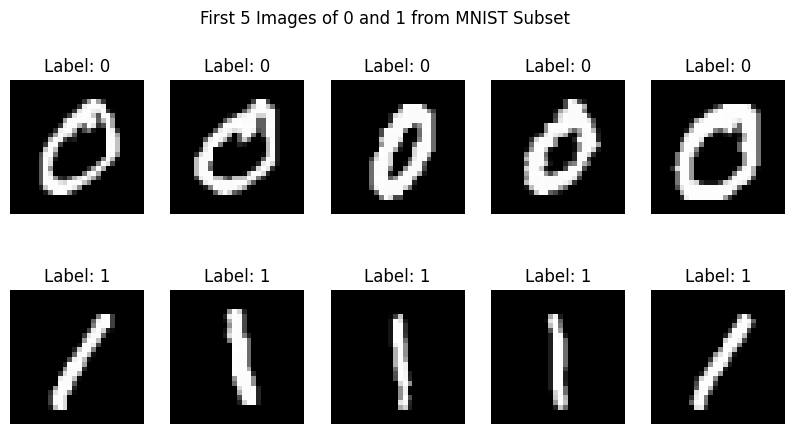

In [ ]:
import matplotlib.pyplot as plt

# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have enough data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

3. Initialize Weights and Bias:

We initialize the weights and bias to zero. This will be used to make predictions for each input.
Initialization of the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Answer the Following Question:
1. Question- 3: What does the weights array represent in this context?




*   Each weight corresponds to one feature (pixel)

*   It determines the importance of each pixel in classification



2. Question- 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

We are initializing the weights to zero because


*  Simple starting point
*  Ensures no bias toward any feature initially

Effect this could have on the training process is that Model starts neutral and learns from data gradually

4. ImplementaDecisionFunctionorActivationFunction:


Assuming we have already learn the weights we will implement a step function which serves as an
decision function for perceptron.




ImplementationDecisionFunction

In [ ]:
import numpy as np

def decision_function(X, weights, bias):

    """
    Computethepredictedlabelsfortheinputdata.
    Parameters:-X:Features(inputdata)asanumpyarrayofshape(n_samples,n_features)-weights:Updatedweightsaftertraining-bias:Updatedbiasaftertraining
    Returns:-y_pred_all:Thepredictedlabelsfortheinputdata
    """
    predictions = np.dot(X, weights) + bias

    # Step function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

5. Implement the Perceptron Learning Algorithm:

Now, we will  implement the main function train perceptron of the Perceptron algorithm. The algorithm
will iterate over the dataset,compute the output,and update the weights and bias if the prediction is incorrect.

Training the Perceptron:

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    """
    TraintheperceptronusingthePerceptronLearningAlgorithm.
    Parameters:-X:Features(inputdata)asanumpyarrayofshape(n_samples,n_features)-y:Labels(trueoutput)asanumpyarrayofshape(n_samples,)-weights:Initialweightsasanumpyarrayofshape(n_features,)-bias:Initialbiasvalue(scalar)-learning_rate:Learningrateforweightupdates(defaultis0.1)-epochs:Numberofiterationstotrainthemodel(defaultis100)
    Returns:-weights:Updatedweightsaftertraining-bias:Updatedbiasaftertraining-accuracy:Totalcorrectprediction.
    """
# Step3:PerceptronLearningAlgorithm
# YourCodehere

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias

            # Prediction using step function
            y_hat = 1 if output >= 0 else 0

            # If prediction is correct
            if y_hat == y[i]:
                correct += 1
            else:
                # Update weights and bias
                weights = weights + learning_rate * (y[i] - y_hat) * X[i]
                bias = bias + learning_rate * (y[i] - y_hat)

        # Accuracy per epoch (optional)
        accuracy = correct / len(X)

    return weights, bias, accuracy

AnswertheFollowingQuestion:
1. Question-5:What is the purpose of the output = np.dot(X[i],weights)+biasline?


The purpose of output = np.dot(X[i], weights) + bias are:
Computes weighted sum of inputs
Determines decision boundary
Used to make prediction

2. Question- 6: What happens when the prediction is wrong? How are the weights and
bias updated?


When the prediction is wrong, we update the weights and bias to reduce the error.
Weights update:
w = w + learning_rate * (y - y_hat) * x

Bias update:
b = b + learning_rate * (y - y_hat)

This adjustment helps the model learn from mistakes and improve future predictions.

3. Question- 7:Why is the final accuracy important, and what do you expect it to be?

Final accuracy is important because:



*   It measures the model's performance.
*   It shows how well the model has learned from the data.

Expected result:

Accuracy should be close to 1.0 (or 100%) for problems like 0 vs 1, because they are linearly separable



6. Putting it all Together:

Train the perceptron algorithm on whole dataset:




Training the Perceptron Algorithm:

In [ ]:
# Initialize weights and bias before training
# The number of features is X.shape[1]
weights = np.zeros(X.shape[1])
bias = 0.0

# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


7. Visualizing the Misclassified Image:
Finally, let’s visualize the images where the model made incorrect predictions. If all images were correctly
classified, print a message indicating this.



Visualizing Misclassified Image

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:
1. Question- 8:What does misclassified idx store, and how is it used in this code?

misclassified_idx stores the indices of the data points (images) that were wrongly classified (where prediction ≠ actual value).

It is used to find which images the model got wrong, display/visualize those misclassified images for analysis

2. Question- 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

It means:

The model achieved 100% accuracy

All predictions are correct (perfect classification)

The data is likely linearly separable

4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.
1. Objective:

In this exercise, you will implement a Perceptron learning algorithm for binary classification using the
MNIST dataset. Specifically, you will classify the digits 3 and 5. After completing the Perceptron
algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_3_and_5.csv

4.5 To- Do:
1. Implement each Step as we implemented above.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI AND MACHINE LEARNING/week3/mnist_3_and_5.csv")  # update path if needed

# Features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2741, 784)
Shape of y: (2741,)


2. Visualize the final misclassified images and Provide your conclusion.

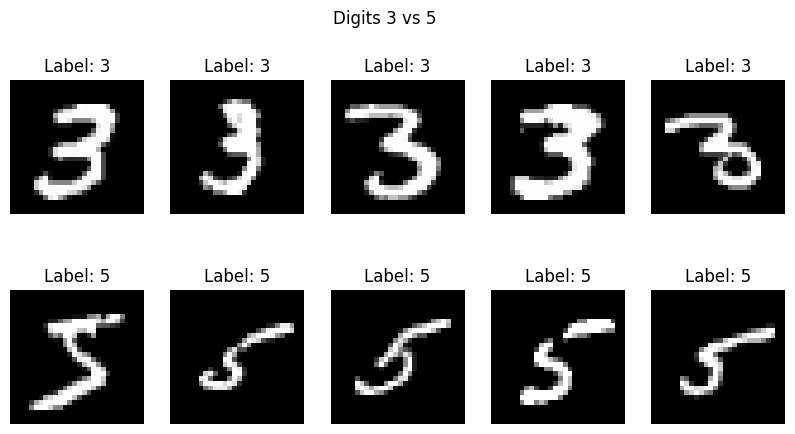

In [ ]:
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("Digits 3 vs 5")
plt.show()

IMPORTANT CHANGE

Perceptron works best with 0 and 1

So convert labels:

In [ ]:
y = np.where(y == 3, 0, 1)  # 3 → 0, 5 → 1

Step 3: Initialize

In [ ]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)


def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_hat = 1 if output >= 0 else 0

            if y_hat == y[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (y[i] - y_hat) * X[i]
                bias = bias + learning_rate * (y[i] - y_hat)

        accuracy = correct / len(X)

    return weights, bias, accuracy

Step 5: Train Model

In [ ]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.9883254286756659


Step 6: Visualize Misclassified Images

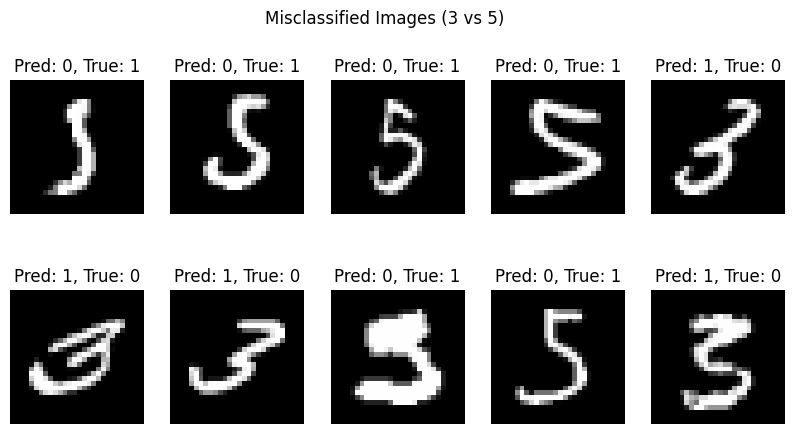

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

The perceptron model was successfully applied to classify digits 3 and 5.

Compared to 0 vs 1 classification, this task is more difficult because digits 3 and 5 are visually similar.

As a result, the model may produce some misclassifications.

This demonstrates the limitation of perceptron, as it can only handle linearly separable data.

For more complex patterns like 3 vs 5, more advanced models (e.g., multi-layer neural networks) are required.